## Rotary Power Spectra and CTD Profiles near Terra Nova Bay 

In [74]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs
import geopandas as gpd
from shapely.ops import unary_union

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.patches as mpatches
import gsw

In [75]:
bath = xr.open_dataset('/Users/mackenzie/Documents/Research/PhD/TNB_Research/data/gebco_2024_n-66.2651_s-87.7985_w159.418_e213.2403.nc')

In [76]:
# Mooring location (constant lat/lon)
tnbd_lat = -75.0112
tnbd_lon = 165.5562

ditd_lat = -75.2751
ditd_lon = 164.0625

D_lat = -75.133
D_lon = 164.542

ditn_lat = -75.36083
ditn_lon = 164.7463

p2_lat = -71.4601
p2_lon = 172.3024

p3_lat = -71.9181
p3_lon = 172.9265

ldeo_lat = -74.97
ldeo_lon = 163.96

dits_lat = -75.4886
dits_lon = 163.2042

In [77]:
gdf = gpd.read_file("/Users/mackenzie/Documents/Research/PhD/TNB_Research/data/add_coastline_high_res_polygon_v7.2/add_coastline_high_res_polygon_v7.2.shp")

In [78]:
# make sure it is in lon/lat
if gdf.crs is not None:
    gdf = gdf.to_crs("EPSG:4326")

ice = gdf[gdf["surface"].isin(["ice shelf", "ice tongue"])]
land = gdf[gdf["surface"].isin(["land"])]

In [79]:
ice

,gid,surface,geometry
3,4,ice shelf,"POLYGON ((-148.67472 -76.2496, -148.67522 -76...."
4,5,ice shelf,"POLYGON ((-149.0105 -76.29985, -149.01101 -76...."
9,9,ice shelf,"POLYGON ((-155.3242 -77.17224, -155.32535 -77...."
11,11,ice shelf,"POLYGON ((-156.99909 -77.36625, -156.9997 -77...."
34,30,ice shelf,"POLYGON ((-145.50682 -76.43536, -145.50735 -76..."
...,...,...,...
17600,17600,ice shelf,"POLYGON ((14.2519 -69.45779, 14.27771 -69.4566..."
17601,17601,ice shelf,"POLYGON ((-151.65936 -85.37647, -151.6609 -85...."
17602,17602,ice shelf,"POLYGON ((-89.05168 -72.94505, -89.05187 -72.9..."
17605,17605,ice shelf,"POLYGON ((-0.13911 -69.53316, -0.073 -69.53852..."


In [80]:
from shapely.geometry import box

region = box(162, -75.75, 170, -74.25)
ice_clip = ice.clip(region)
land_clip = land.clip(region)

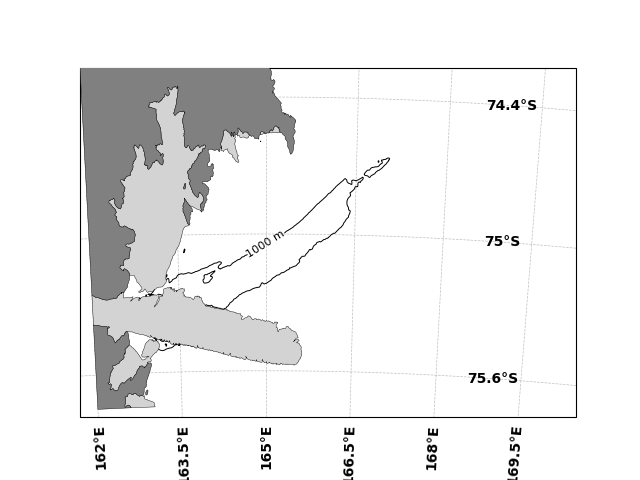

In [81]:
# starting from scratch... this is so fucking annoying 

# step 1: set lat/lon extent 
# --- Define your region ---
lon_min, lon_max = 150, 180
lat_min, lat_max = -80, -70

# step 2: 
proj = ccrs.SouthPolarStereo(central_longitude=165)

fig, ax = plt.subplots(subplot_kw={"projection": proj})

ax.set_extent([162, 170, -75.75, -74.25], crs=ccrs.PlateCarree())

gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.5,
    color='gray',
    alpha=0.5,
    linestyle='--'
)

gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10, 'weight': 'bold'}
gl.ylabel_style = {'size': 10, 'weight': 'bold'}

# set latitude tick marks 
gl.ylocator = plt.FixedLocator([-75.6,-75, -74.4])
depth = -bath.sel(lat=slice(lat_min,lat_max),lon=slice(lon_min,lon_max))['elevation']

levels = [1000]

contours = ax.contour(
    depth['lon'],
    depth['lat'],
    depth,
    levels=levels,
    colors='black',
    linewidths=0.7,
    transform=ccrs.PlateCarree(),
    zorder=2
)
ax.clabel(contours, fmt='%d m', fontsize=8, inline=True, inline_spacing=1)

ax.add_geometries(
    ice_clip.geometry,
    crs=ccrs.PlateCarree(),
    facecolor='lightgrey',
    edgecolor='k',
    linewidth=0.3,
    zorder=3
)

ax.add_geometries(
    land_clip.geometry,
    crs=ccrs.PlateCarree(),
    facecolor='grey',
    edgecolor='k',
    linewidth=0.3,
    zorder=3
)


In [82]:
# make into a function 
def TNB_study_site():
    """
    """
    # step 2: 
    proj = ccrs.SouthPolarStereo(central_longitude=165)

    fig, ax = plt.subplots(subplot_kw={"projection": proj})

    ax.set_extent([162, 170, -75.75, -74.25], crs=ccrs.PlateCarree())

    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=0.5,
        color='gray',
        alpha=0.5,
        linestyle='--'
    )

    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 10, 'weight': 'bold'}
    gl.ylabel_style = {'size': 10, 'weight': 'bold'}
    # set latitude tick marks 
    gl.ylocator = plt.FixedLocator([-75.6,-75, -74.4])

    depth = -bath.sel(lat=slice(lat_min,lat_max),lon=slice(lon_min,lon_max))['elevation']

    levels = [1000]

    contours = ax.contour(
        depth['lon'],
        depth['lat'],
        depth,
        levels=levels,
        colors='black',
        linewidths=0.7,
        transform=ccrs.PlateCarree(),
        zorder=2
    )
    ax.clabel(contours, fmt='%d m', fontsize=8, inline=True, inline_spacing=1)

    ax.add_geometries(
        ice_clip.geometry,
        crs=ccrs.PlateCarree(),
        facecolor='lightgrey',
        edgecolor='k',
        linewidth=0.3,
        zorder=3
    )

    ax.add_geometries(
        land_clip.geometry,
        crs=ccrs.PlateCarree(),
        facecolor='grey',
        edgecolor='k',
        linewidth=0.3,
        zorder=3
    )
    return fig, ax


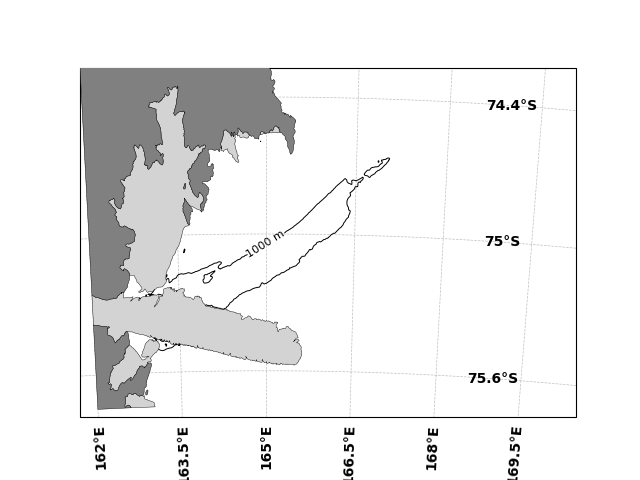

In [83]:
fig, ax = TNB_study_site()

In [1]:
import xarray as xr 
import matplotlib.pyplot as plt 
import numpy as np 
from scipy.signal import welch, csd
import pandas as pd


### Rotary Power Spectra 

**Goal:** Apply correlation and spectral relations to a vector timeseries (i.e. ocean currents) that is influenced by Earth's rotation. Earth's rotation can cause an asymmetry in fourier coefficients and we seek statistical relations that are invariant to rotation. 

A given velocity can be decomposed into a real and imaginary part, 

$$ u = u + iv $$

where $ i = \sqrt{-1} $

In Gonella (1972), four quantities are deemed useful: 

1. The mean kinetic energy (i.e. the total spectrum)

2. The rotary coefficient 

3. The orientation of the ellipse 

4. The stability of the ellipse 

Expanding on these, 

The mean kinetic energy, or the total spectrum, is defined as the summation of the clockwise ($ S_{-} $) and counterclockwise ($ S_{+} $) spectrums, 

$$ S_{t} = S_{-} + S_{+} $$

The rotary coefficient is defined as, 

$$ C_{R} = (S_{-} - S_{+}) / (S_{-} + S_{+}) $$



In [2]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.signal import welch, csd

# def rotary_spectrum(u, v, fs, nperseg=256, **kwargs):
#     """
#     Compute the rotary power spectrum of 2D current data.

#     Parameters
#     ----------
#     u : array-like  — eastward velocity
#     v : array-like  — northward velocity
#     fs : float      — sampling frequency (Hz)
#     nperseg : int   — samples per Welch segment

#     Returns
#     -------
#     freq : ndarray  — frequencies (Hz), positive only
#     S_ccw : ndarray — CCW (counter-clockwise) spectrum
#     S_cw  : ndarray — CW  (clockwise) spectrum
#     """
#     # Auto- and cross-spectra using Welch's method
#     freq, Suu = welch(u, fs=fs, nperseg=nperseg, **kwargs)
#     _,    Svv = welch(v, fs=fs, nperseg=nperseg, **kwargs)
#     _,    Cuv = csd (u, v, fs=fs, nperseg=nperseg, **kwargs)  # complex cross-spectrum

#     # Rotary components
#     # S_ccw = (Suu + Svv + 2*Im(Cuv)) / 4   (CCW / positive freq)
#     # S_cw  = (Suu + Svv - 2*Im(Cuv)) / 4   (CW  / negative freq)
#     S_ccw = (Suu + Svv + 2 * np.imag(Cuv)) / 4
#     S_cw  = (Suu + Svv - 2 * np.imag(Cuv)) / 4

#     return freq, S_ccw, S_cw


# def rotary_coefficient(S_ccw, S_cw):
#     """
#     Rotary coefficient: +1 = pure CCW, -1 = pure CW, 0 = linear.
#     """
#     return (S_ccw - S_cw) / (S_ccw + S_cw)


# # --- Example usage ---
# fs = 1 / 3600          # 1-hour sampling → fs in Hz
# N  = 4096
# t  = np.arange(N) / fs

# # Synthetic inertial oscillation (CW in Northern Hemisphere)
# f_inertial = 1 / (18 * 3600)   # ~18-hour period
# u =  np.cos(2 * np.pi * f_inertial * t) + 0.1 * np.random.randn(N)
# v = -np.sin(2 * np.pi * f_inertial * t) + 0.1 * np.random.randn(N)

# freq, S_ccw, S_cw = rotary_spectrum(u, v, fs=fs, nperseg=512,
#                                     window='hann', detrend='linear')

# # Convert freq to cycles per day for oceanographic convention
# cpd = freq * 86400

# # --- Plot ---
# fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# ax = axes[0]
# ax.semilogy(cpd, S_ccw, label='CCW (+)', color='steelblue')
# ax.semilogy(cpd, S_cw,  label='CW  (−)', color='tomato', linestyle='--')
# ax.axvline(f_inertial * 86400, color='gray', linestyle=':', label='f_inertial')
# ax.set_ylabel('Power spectral density [(m/s)²/cpd]')
# ax.set_title('Rotary Power Spectrum')
# ax.legend()
# ax.grid(True, which='both', alpha=0.3)

# rc = rotary_coefficient(S_ccw, S_cw)
# axes[1].plot(cpd, rc, color='purple')
# axes[1].axhline(0, color='k', linewidth=0.8)
# axes[1].set_xlabel('Frequency [cpd]')
# axes[1].set_ylabel('Rotary coefficient')
# axes[1].set_title('Rotary Coefficient (−1 = CW, +1 = CCW)')
# axes[1].set_ylim(-1.1, 1.1)
# axes[1].grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

In [3]:
# load in TNBD current meter data from bottom sensor (~1130 meters)
vel = xr.open_dataset('/Users/mackenzie/Documents/Research/PhD/TNB_tools/MastersThesis/tnbd_2018_vel_bot_1093.nc')

In [4]:
vel

<xarray.Dataset> Size: 2MB
Dimensions:  (time: 28610)
Coordinates:
  * time     (time) datetime64[ns] 229kB 2018-03-12 ... 2019-01-03T23:59:54
    lat      float64 8B ...
    lon      float64 8B ...
    z        int64 8B ...
Data variables:
    u        (time) float64 229kB ...
    v        (time) float64 229kB ...
    w        (time) float64 229kB ...
    pres     (time) float64 229kB ...
    speed    (time) float64 229kB ...
    dir      (time) float64 229kB ...

In [5]:
# step 1: define u, v, fs, and nperseg (to be used in power spectra calculation)
u = vel.u
v= vel.v
fs = 1/900 # 15 minutes
nperseg = 5722

# other nperseg values to try: 
# 5722 --> 5 segments 
# 4096 --> 13 segments 
# 2048 --> 27 segments 
# 1024 --> 55 segments 

In [6]:
# step2: compute auto spectra 
# computing spectra using welch function from scipy 
# This function segments the data into a certain amount and takes the average spectra 

freq, Suu = welch(u,fs=fs, nperseg=nperseg)
_, Svv = welch(v,fs=fs, nperseg=nperseg)

In [7]:
Svv

array([3.27189662e+06, 1.18995350e+07, 1.07293936e+07, ...,
       2.18020081e+03, 1.49034273e+03, 6.89296608e+02], shape=(2862,))

In [8]:
# step 3: compute cross spectra 
_, Cuv = csd(u,v,fs=fs, nperseg=nperseg)

In [9]:
Suu

array([1.09195171e+06, 7.55109401e+06, 5.18492487e+06, ...,
       1.63002362e+03, 1.24783569e+03, 4.97358073e+02], shape=(2862,))

In [10]:
# step 4: split into clockwise and anticlockwise rotary components 
S_ccw = (Suu + Svv + 2*np.imag(Cuv))/4

S_cw = (Suu + Svv - 2*np.imag(Cuv))/4

In [11]:
%matplotlib widget

Text(0.5, 0, 'Period (hours)')

/var/folders/yh/gzfzh54j7n572slt5126rl3m0000gn/T/ipykernel_49485/1998609681.py:16: RuntimeWarning: divide by zero encountered in divide
  return 24 / t


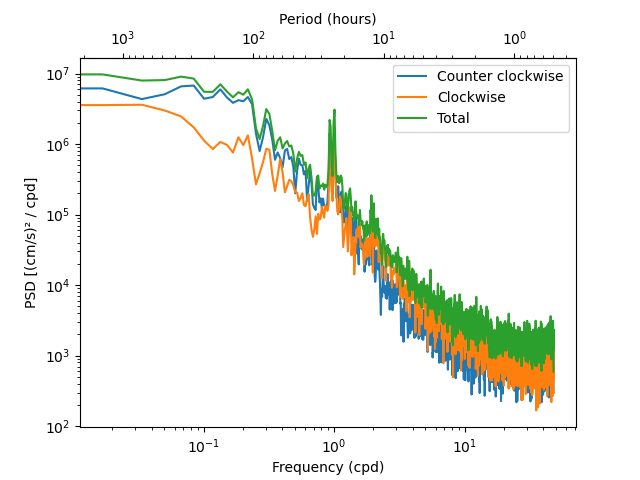

In [12]:
fig = plt.figure()
plt.loglog(freq * 86400, S_ccw, label='Counter clockwise')
plt.loglog(freq * 86400, S_cw,  label='Clockwise')
plt.loglog(freq * 86400, (S_ccw + S_cw), label='Total')
plt.legend()
plt.xlabel('Frequency (cpd)')
plt.ylabel('PSD [(cm/s)² / cpd]')

# Grab the current axis to add the secondary axis
ax = plt.gca()

def cpd_to_hours(f):
    return 24 / f

def hours_to_cpd(t):
    return 24 / t

secax = ax.secondary_xaxis('top', functions=(cpd_to_hours, hours_to_cpd))
secax.set_xlabel('Period (hours)')


### CTD data 

In [3]:
# load data - MAC 
df = pd.read_csv('/Users/mackenzie/Documents/Research/PhD/TNB_Research/data/ctd_012018_palmer.csv')

# Use station as the only dimension
ds = df.set_index('Station').to_xarray()

In [4]:
ds.sel(Station=1)

<xarray.Dataset> Size: 317kB
Dimensions:                  (Station: 1522)
Coordinates:
  * Station                  (Station) int64 12kB 1 1 1 1 1 1 1 ... 1 1 1 1 1 1
Data variables: (12/25)
    Date                     (Station) object 12kB '2017-12-26' ... '2017-12-26'
    Julian_Day               (Station) float64 12kB 360.8 360.8 ... 360.8 360.8
    ISO_DateTime_UTC         (Station) object 12kB '2017-12-26T19:16:13Z' ......
    Pressure                 (Station) int64 12kB 1 2 3 4 ... 1520 1521 1522
    Depth                    (Station) float64 12kB 0.987 1.979 ... 1.502e+03
    Temperature              (Station) float64 12kB 1.25 1.248 ... 1.809 1.809
    ...                       ...
    Scan_Count               (Station) int64 12kB 12923 13003 ... 63488 64191
    Salinity                 (Station) float64 12kB 33.81 33.81 ... 34.72 34.72
    Salinity_2               (Station) float64 12kB 33.81 33.81 ... 34.73 34.73
    Oxygen_Saturation        (Station) float64 12kB 7.82 7.821 ... 7.662 7.662
    Scans_bin                (Station) int64 12kB 22 45 52 41 44 ... 43 50 47 7
    Flag                     (Station) float64 12kB 0.0 0.0 0.0 ... 0.0 0.0 0.0

In [5]:
# need to reformat data 
# ds format: dims: (station, sample)
print(ds)

<xarray.Dataset> Size: 12MB
Dimensions:                  (Station: 57899)
Coordinates:
  * Station                  (Station) int64 463kB 1 1 1 1 1 ... 80 80 80 80 80
Data variables: (12/25)
    Date                     (Station) object 463kB '2017-12-26' ... '2018-02...
    Julian_Day               (Station) float64 463kB 360.8 360.8 ... 50.23 50.23
    ISO_DateTime_UTC         (Station) object 463kB '2017-12-26T19:16:13Z' .....
    Pressure                 (Station) int64 463kB 1 2 3 4 5 ... 681 682 683 684
    Depth                    (Station) float64 463kB 0.987 1.979 ... 674.8 675.8
    Temperature              (Station) float64 463kB 1.25 1.248 ... -1.928
    ...                       ...
    Scan_Count               (Station) int64 463kB 12923 13003 ... 32113 32467
    Salinity                 (Station) float64 463kB 33.81 33.81 ... 34.77 34.77
    Salinity_2               (Station) float64 463kB 33.81 33.81 ... 34.77 34.77
    Oxygen_Saturation        (Station) float64 463kB 7

In [6]:
ds

<xarray.Dataset> Size: 12MB
Dimensions:                  (Station: 57899)
Coordinates:
  * Station                  (Station) int64 463kB 1 1 1 1 1 ... 80 80 80 80 80
Data variables: (12/25)
    Date                     (Station) object 463kB '2017-12-26' ... '2018-02...
    Julian_Day               (Station) float64 463kB 360.8 360.8 ... 50.23 50.23
    ISO_DateTime_UTC         (Station) object 463kB '2017-12-26T19:16:13Z' .....
    Pressure                 (Station) int64 463kB 1 2 3 4 5 ... 681 682 683 684
    Depth                    (Station) float64 463kB 0.987 1.979 ... 674.8 675.8
    Temperature              (Station) float64 463kB 1.25 1.248 ... -1.928
    ...                       ...
    Scan_Count               (Station) int64 463kB 12923 13003 ... 32113 32467
    Salinity                 (Station) float64 463kB 33.81 33.81 ... 34.77 34.77
    Salinity_2               (Station) float64 463kB 33.81 33.81 ... 34.77 34.77
    Oxygen_Saturation        (Station) float64 463kB 7.82 7.821 ... 8.445 8.445
    Scans_bin                (Station) int64 463kB 22 45 52 41 ... 44 42 52 66
    Flag                     (Station) float64 463kB 0.0 0.0 0.0 ... 0.0 0.0 0.0

In [ ]:
# 1. Rename the current dimension to something honest
ds1 = ds.rename_dims({'Station': 'obs'}).rename_vars({'Station': 'station'})

# 2. Build a sample index within each station
station_vals = ds1['station'].values

sample = np.zeros(len(station_vals), dtype=int)
count = {}

for i, st in enumerate(station_vals):
    sample[i] = count.get(st, 0)
    count[st] = count.get(st, 0) + 1

# 3. Attach sample as a coordinate on obs
ds_sub2 = ds_sub2.assign_coords(sample=('obs', sample))

# 4. Reshape from long -> 2D
ds2 = ds1.set_index(obs=['station', 'sample']).unstack('obs')

print(ds2)

<xarray.Dataset> Size: 24MB
Dimensions:                  (station: 79, sample: 1522)
Coordinates:
  * station                  (station) int64 632B 1 3 4 5 6 7 ... 76 77 78 79 80
  * sample                   (sample) int64 12kB 0 1 2 3 ... 1518 1519 1520 1521
Data variables: (12/25)
    Date                     (station, sample) object 962kB '2017-12-26' ... nan
    Julian_Day               (station, sample) float64 962kB 360.8 360.8 ... nan
    ISO_DateTime_UTC         (station, sample) object 962kB '2017-12-26T19:16...
    Pressure                 (station, sample) float64 962kB 1.0 2.0 ... nan nan
    Depth                    (station, sample) float64 962kB 0.987 1.979 ... nan
    Temperature              (station, sample) float64 962kB 1.25 1.248 ... nan
    ...                       ...
    Scan_Count               (station, sample) float64 962kB 1.292e+04 ... nan
    Salinity                 (station, sample) float64 962kB 33.81 33.81 ... nan
    Salinity_2               (station

In [23]:
ds2

<xarray.Dataset> Size: 24MB
Dimensions:                  (station: 79, sample: 1522)
Coordinates:
  * station                  (station) int64 632B 1 3 4 5 6 7 ... 76 77 78 79 80
  * sample                   (sample) int64 12kB 0 1 2 3 ... 1518 1519 1520 1521
Data variables: (12/25)
    Date                     (station, sample) object 962kB '2017-12-26' ... nan
    Julian_Day               (station, sample) float64 962kB 360.8 360.8 ... nan
    ISO_DateTime_UTC         (station, sample) object 962kB '2017-12-26T19:16...
    Pressure                 (station, sample) float64 962kB 1.0 2.0 ... nan nan
    Depth                    (station, sample) float64 962kB 0.987 1.979 ... nan
    Temperature              (station, sample) float64 962kB 1.25 1.248 ... nan
    ...                       ...
    Scan_Count               (station, sample) float64 962kB 1.292e+04 ... nan
    Salinity                 (station, sample) float64 962kB 33.81 33.81 ... nan
    Salinity_2               (station, sample) float64 962kB 33.81 33.81 ... nan
    Oxygen_Saturation        (station, sample) float64 962kB 7.82 7.821 ... nan
    Scans_bin                (station, sample) float64 962kB 22.0 45.0 ... nan
    Flag                     (station, sample) float64 962kB 0.0 0.0 ... nan nan

In [25]:
str(station_sel)

'0'

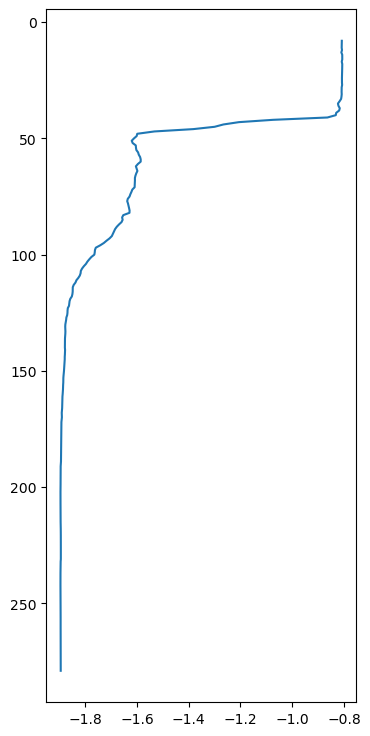

In [30]:
# plot a cast 
# define station to easily sub in 
station_sel = 70
fig = plt.figure(figsize=(4,9))
plt.plot(ds2.sel(station=station_sel).Temperature,ds2.sel(station=station_sel).Pressure)
plt.gca().invert_yaxis()

In [33]:
# reformat lat / lon to be coordinates 
lat1d = ds2['Latitude'].isel(sample=0)
lon1d = ds2['Longitude'].isel(sample=0)

ds2 = ds2.assign_coords(
    lat=('station', lat1d.values),
    lon=('station', lon1d.values)
)

In [34]:
ds2 = ds2.drop_vars(['Latitude', 'Longitude'])

In [35]:
ds2

<xarray.Dataset> Size: 22MB
Dimensions:                  (station: 79, sample: 1522)
Coordinates:
  * station                  (station) int64 632B 1 3 4 5 6 7 ... 76 77 78 79 80
  * sample                   (sample) int64 12kB 0 1 2 3 ... 1518 1519 1520 1521
    lat                      (station) float64 632B -64.72 -70.17 ... -74.86
    lon                      (station) float64 632B -87.28 -113.6 ... 164.9
Data variables: (12/23)
    Date                     (station, sample) object 962kB '2017-12-26' ... nan
    Julian_Day               (station, sample) float64 962kB 360.8 360.8 ... nan
    ISO_DateTime_UTC         (station, sample) object 962kB '2017-12-26T19:16...
    Pressure                 (station, sample) float64 962kB 1.0 2.0 ... nan nan
    Depth                    (station, sample) float64 962kB 0.987 1.979 ... nan
    Temperature              (station, sample) float64 962kB 1.25 1.248 ... nan
    ...                       ...
    Scan_Count               (station, sample) float64 962kB 1.292e+04 ... nan
    Salinity                 (station, sample) float64 962kB 33.81 33.81 ... nan
    Salinity_2               (station, sample) float64 962kB 33.81 33.81 ... nan
    Oxygen_Saturation        (station, sample) float64 962kB 7.82 7.821 ... nan
    Scans_bin                (station, sample) float64 962kB 22.0 45.0 ... nan
    Flag                     (station, sample) float64 962kB 0.0 0.0 ... nan nan

In [36]:
ds_sub = ds2.where(
    (ds2.lon > 163) & (ds2.lon < 167) &
    (ds2.lat > -76) & (ds2.lat < -74),
    drop=True
)

In [37]:
ds_sub

<xarray.Dataset> Size: 11MB
Dimensions:                  (station: 41, sample: 1522)
Coordinates:
  * station                  (station) int64 328B 22 23 24 25 26 ... 77 78 79 80
  * sample                   (sample) int64 12kB 0 1 2 3 ... 1518 1519 1520 1521
    lat                      (station) float64 328B -75.0 -75.0 ... -74.86
    lon                      (station) float64 328B 165.4 165.8 ... 164.8 164.9
Data variables: (12/23)
    Date                     (station, sample) object 499kB '2018-01-09' ... nan
    Julian_Day               (station, sample) float64 499kB 9.197 9.197 ... nan
    ISO_DateTime_UTC         (station, sample) object 499kB '2018-01-09T04:43...
    Pressure                 (station, sample) float64 499kB 1.0 2.0 ... nan nan
    Depth                    (station, sample) float64 499kB 0.982 1.978 ... nan
    Temperature              (station, sample) float64 499kB 0.7381 ... nan
    ...                       ...
    Scan_Count               (station, sample) float64 499kB 7.5e+03 ... nan
    Salinity                 (station, sample) float64 499kB 34.56 34.56 ... nan
    Salinity_2               (station, sample) float64 499kB 34.57 34.57 ... nan
    Oxygen_Saturation        (station, sample) float64 499kB 7.883 7.883 ... nan
    Scans_bin                (station, sample) float64 499kB 25.0 53.0 ... nan
    Flag                     (station, sample) float64 499kB 0.0 0.0 ... nan nan

Text(0.5, 1.0, 'Map 3: CTD Casts in TNB Drygalski Trough')

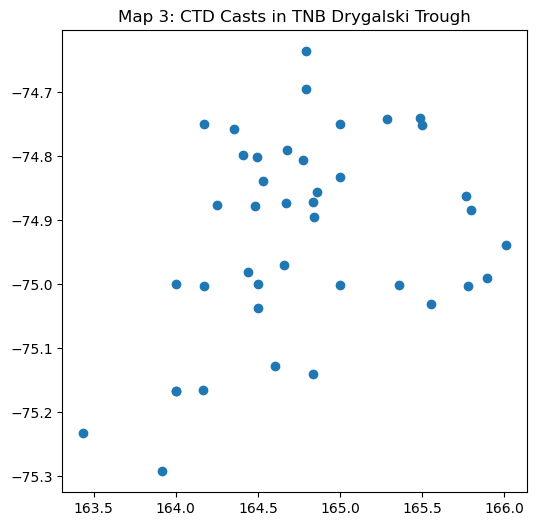

In [39]:
fig = plt.figure(figsize=(6,6))
plt.scatter(ds_sub.lon,ds_sub.lat)
plt.title('Map 3: CTD Casts in TNB Drygalski Trough')

In [40]:
# calculate TEOS-10 variables 
import gsw

In [43]:
ds_sub['Absolute_Salinity'] = gsw.SA_from_SP(ds_sub.Salinity,ds_sub.Pressure,ds_sub.lon,ds_sub.lat)
# should a reference pressure of zero be used? 
ds_sub['Potential_Temperature'] = gsw.pt_from_t(ds_sub.Absolute_Salinity,ds_sub.Temperature,ds_sub.Pressure,0)
ds_sub['Conservative_Temperature'] = gsw.CT_from_pt(ds_sub.Absolute_Salinity,ds_sub.Potential_Temperature)
ds_sub['Potential_Density'] = gsw.sigma0(ds_sub.Absolute_Salinity,ds_sub.Conservative_Temperature)

In [64]:
ds_sub

<xarray.Dataset> Size: 13MB
Dimensions:                   (station: 41, sample: 1522)
Coordinates:
  * station                   (station) int64 328B 22 23 24 25 ... 77 78 79 80
  * sample                    (sample) int64 12kB 0 1 2 3 ... 1519 1520 1521
    lat                       (station) float64 328B -75.0 -75.0 ... -74.86
    lon                       (station) float64 328B 165.4 165.8 ... 164.8 164.9
Data variables: (12/27)
    Date                      (station, sample) object 499kB '2018-01-09' ......
    Julian_Day                (station, sample) float64 499kB 9.197 ... nan
    ISO_DateTime_UTC          (station, sample) object 499kB '2018-01-09T04:4...
    Pressure                  (station, sample) float64 499kB 1.0 2.0 ... nan
    Depth                     (station, sample) float64 499kB 0.982 ... nan
    Temperature               (station, sample) float64 499kB 0.7381 ... nan
    ...                        ...
    Scans_bin                 (station, sample) float64 499kB 25.0 53.0 ... nan
    Flag                      (station, sample) float64 499kB 0.0 0.0 ... nan
    Absolute_Salinity         (station, sample) float64 499kB 34.73 ... nan
    Potential_Temperature     (station, sample) float64 499kB 0.7381 ... nan
    Conservative_Temperature  (station, sample) float64 499kB 0.7394 ... nan
    Potential_Density         (station, sample) float64 499kB 27.71 ... nan

In [70]:
%matplotlib widget 

In [73]:
# # plot casts 
# station = 26
# fig = plt.figure(figsize=(9,6), constrained_layout=True)

# # 1st panel 
# plt.subplot(131)
# # plt.plot(ds_sub.isel(station=station).Temperature,ds_sub.isel(station=station).Pressure)
# # plt.plot(ds_sub.isel(station=station).Conservative_Temperature,ds_sub.isel(station=station).Pressure)
# plt.plot(ds_sub.sel(station=station).Potential_Temperature,ds_sub.sel(station=station).Pressure)
# plt.xlabel('Potential Temperature \n [deg C]')
# plt.ylabel('Pressure [dbar]')
# plt.gca().invert_yaxis()

# # 2nd panel 
# plt.subplot(132)
# plt.plot(ds_sub.sel(station=station).Absolute_Salinity,ds_sub.sel(station=station).Pressure)
# plt.xlabel('Absolute Salinity \n [g/kg]')
# plt.gca().invert_yaxis()

# # 3rd panel 
# plt.subplot(133)
# plt.plot(ds_sub.sel(station=station).Potential_Density,ds_sub.sel(station=station).Pressure)
# plt.xlabel('Potential Density \n [kg/m^3]')
# plt.gca().invert_yaxis()

# st_num = ds_sub.station.sel(station=station).item()
# date = ds_sub.Date.sel(station=station).isel(sample=0).item()  # or use Date variable version

# plt.suptitle(f'Station {st_num}, {date}')


In [88]:
plt.close('all')

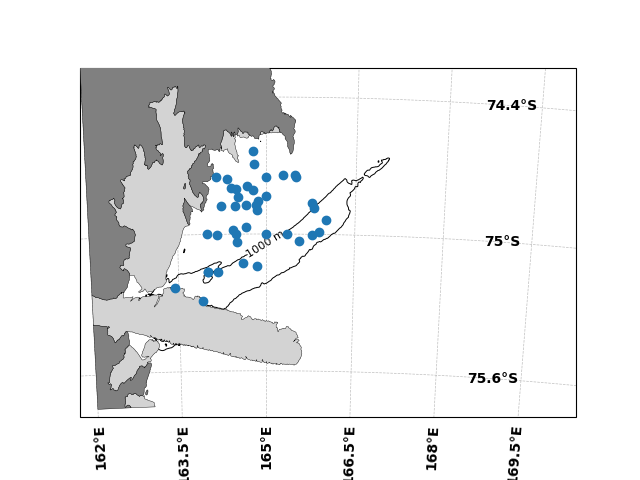

In [87]:
fig, ax = TNB_study_site()
ax.scatter(ds_sub.lon,ds_sub.lat,transform=ccrs.PlateCarree(),
        zorder=10)
# plt.title('Map 3: CTD Casts in TNB Drygalski Trough')


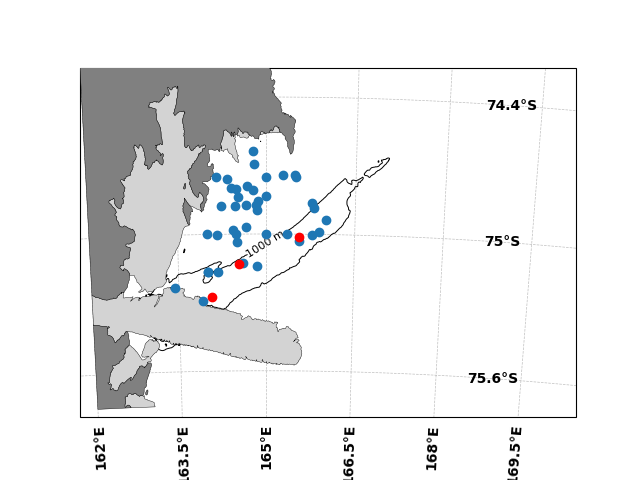

In [91]:
fig, ax = TNB_study_site()

ax.scatter(
    ds_sub.lon,
    ds_sub.lat,
    transform=ccrs.PlateCarree(),
    zorder=10
)

ax.scatter(ditd_lon,ditd_lat,transform=ccrs.PlateCarree(),
    zorder=10,color='r')
ax.scatter(tnbd_lon,tnbd_lat,transform=ccrs.PlateCarree(),
    zorder=10,color='r')
ax.scatter(D_lon,D_lat,transform=ccrs.PlateCarree(),
    zorder=10,color='r')

# # add station labels
# for i in range(len(ds_sub.station)):
#     ax.text(
#         ds_sub.lon.isel(station=i).item(),
#         ds_sub.lat.isel(station=i).item(),
#         str(ds_sub.station.isel(station=i).item()),
#         transform=ccrs.PlateCarree(),
#         fontsize=8,
#         ha='center',
#         va='bottom',   # puts label above point
#         zorder=11
#     )

Text(0.5, 0.98, 'Station 26, 2018-01-11')

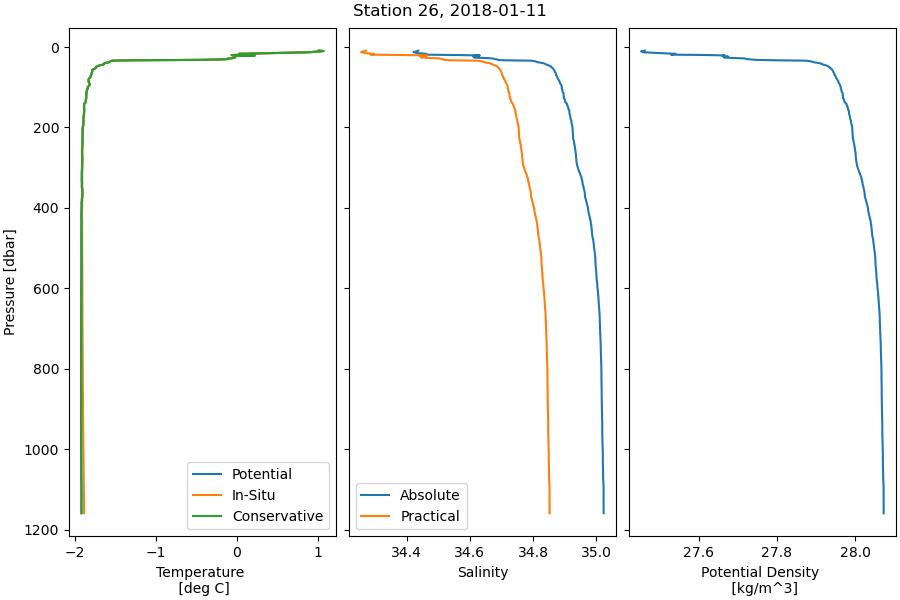

In [118]:
station = 26
ds_st = ds_sub.sel(station=station)

fig, axes = plt.subplots(1, 3, figsize=(9,6), constrained_layout=True, sharey=True)

# 1st panel
axes[0].plot(ds_st.Potential_Temperature, ds_st.Pressure,label='Potential')
axes[0].plot(ds_st.Temperature, ds_st.Pressure,label='In-Situ')
axes[0].plot(ds_st.Conservative_Temperature, ds_st.Pressure,label='Conservative')
axes[0].legend()
axes[0].set_xlabel('Temperature \n [deg C]')
axes[0].set_ylabel('Pressure [dbar]')
axes[0].invert_yaxis()

# 2nd panel
axes[1].plot(ds_st.Absolute_Salinity, ds_st.Pressure,label='Absolute')
axes[1].plot(ds_st.Salinity, ds_st.Pressure,label='Practical')
axes[1].legend()
axes[1].set_xlabel('Salinity')
axes[1].invert_yaxis()

# 3rd panel
axes[2].plot(ds_st.Potential_Density, ds_st.Pressure)
axes[2].set_xlabel('Potential Density \n [kg/m^3]')
axes[2].invert_yaxis()

# Title
st_num = ds_st.station.item()
date = ds_sub.Date.sel(station=station).isel(sample=0).item()

fig.suptitle(f'Station {st_num}, {date}')

### CTD Casts - Map 1 Region (Towards Amundsen Sea)


In [95]:
ds1 = ds2.where(
    (ds2.lon > -150) & (ds2.lon < -80) &
    (ds2.lat > -80) & (ds2.lat < -63),
    drop=True
)

In [97]:
ds1

<xarray.Dataset> Size: 4MB
Dimensions:                  (station: 13, sample: 1522)
Coordinates:
  * station                  (station) int64 104B 1 3 4 5 6 7 8 9 10 11 12 13 14
  * sample                   (sample) int64 12kB 0 1 2 3 ... 1518 1519 1520 1521
    lat                      (station) float64 104B -64.72 -70.17 ... -74.97
    lon                      (station) float64 104B -87.28 -113.6 ... -145.1
Data variables: (12/23)
    Date                     (station, sample) object 158kB '2017-12-26' ... nan
    Julian_Day               (station, sample) float64 158kB 360.8 360.8 ... nan
    ISO_DateTime_UTC         (station, sample) object 158kB '2017-12-26T19:16...
    Pressure                 (station, sample) float64 158kB 1.0 2.0 ... nan nan
    Depth                    (station, sample) float64 158kB 0.987 1.979 ... nan
    Temperature              (station, sample) float64 158kB 1.25 1.248 ... nan
    ...                       ...
    Scan_Count               (station, sample) float64 158kB 1.292e+04 ... nan
    Salinity                 (station, sample) float64 158kB 33.81 33.81 ... nan
    Salinity_2               (station, sample) float64 158kB 33.81 33.81 ... nan
    Oxygen_Saturation        (station, sample) float64 158kB 7.82 7.821 ... nan
    Scans_bin                (station, sample) float64 158kB 22.0 45.0 ... nan
    Flag                     (station, sample) float64 158kB 0.0 0.0 ... nan nan

Text(0.5, 1.0, 'Map 1: CTD Casts Towards Amundsen Sea')

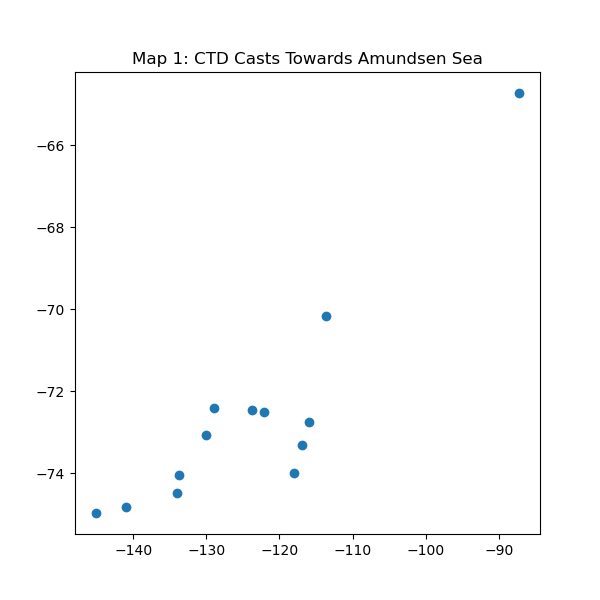

In [98]:
fig = plt.figure(figsize=(6,6))
plt.scatter(ds1.lon,ds1.lat)
plt.title('Map 1: CTD Casts Towards Amundsen Sea')

In [99]:
ds1['Absolute_Salinity'] = gsw.SA_from_SP(ds1.Salinity,ds1.Pressure,ds1.lon,ds1.lat)
# should a reference pressure of zero be used? 
ds1['Potential_Temperature'] = gsw.pt_from_t(ds1.Absolute_Salinity,ds1.Temperature,ds1.Pressure,0)
ds1['Conservative_Temperature'] = gsw.CT_from_pt(ds1.Absolute_Salinity,ds1.Potential_Temperature)
ds1['Potential_Density'] = gsw.sigma0(ds1.Absolute_Salinity,ds1.Conservative_Temperature)

Text(0.5, 0.98, 'Station 13, 2018-01-04')

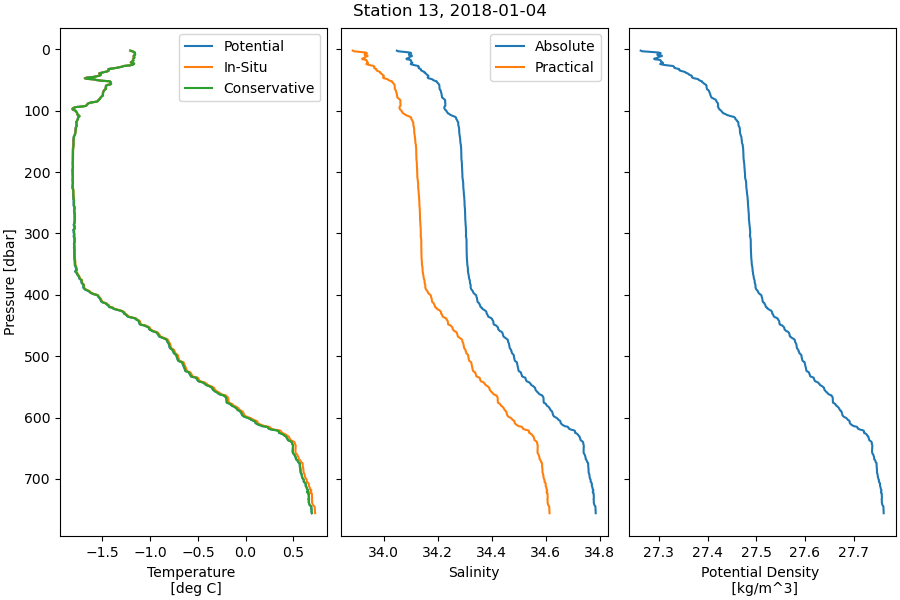

In [123]:
station = 13
ds_st = ds1.sel(station=station)

fig, axes = plt.subplots(1, 3, figsize=(9,6), constrained_layout=True, sharey=True)

# 1st panel
axes[0].plot(ds_st.Potential_Temperature, ds_st.Pressure,label='Potential')
axes[0].plot(ds_st.Temperature, ds_st.Pressure,label='In-Situ')
axes[0].plot(ds_st.Conservative_Temperature, ds_st.Pressure,label='Conservative')
axes[0].legend()
axes[0].set_xlabel('Temperature \n [deg C]')
axes[0].set_ylabel('Pressure [dbar]')
axes[0].invert_yaxis()

# 2nd panel
axes[1].plot(ds_st.Absolute_Salinity, ds_st.Pressure,label='Absolute')
axes[1].plot(ds_st.Salinity, ds_st.Pressure,label='Practical')
axes[1].legend()
axes[1].set_xlabel('Salinity')
axes[1].invert_yaxis()

# 3rd panel
axes[2].plot(ds_st.Potential_Density, ds_st.Pressure)
axes[2].set_xlabel('Potential Density \n [kg/m^3]')
axes[2].invert_yaxis()

# Title
st_num = ds_st.station.item()
date = ds1.Date.sel(station=station).isel(sample=0).item()

fig.suptitle(f'Station {st_num}, {date}')

### Map 2 Region: Ross Sea 

In [110]:
ds_sub2 = ds2.where(
    (ds2.lon > 168) & (ds2.lon < 179) &
    (ds2.lat > -80) & (ds2.lat < -74),
    drop=True
)

In [111]:
ds_sub2

<xarray.Dataset> Size: 5MB
Dimensions:                  (station: 17, sample: 1522)
Coordinates:
  * station                  (station) int64 136B 21 28 29 31 32 ... 68 69 70 71
  * sample                   (sample) int64 12kB 0 1 2 3 ... 1518 1519 1520 1521
    lat                      (station) float64 136B -75.54 -74.75 ... -75.3
    lon                      (station) float64 136B 169.9 173.0 ... 170.5 170.5
Data variables: (12/23)
    Date                     (station, sample) object 207kB '2018-01-08' ... nan
    Julian_Day               (station, sample) float64 207kB 8.666 8.666 ... nan
    ISO_DateTime_UTC         (station, sample) object 207kB '2018-01-08T15:59...
    Pressure                 (station, sample) float64 207kB 9.0 10.0 ... nan
    Depth                    (station, sample) float64 207kB 8.906 9.893 ... nan
    Temperature              (station, sample) float64 207kB 0.7767 ... nan
    ...                       ...
    Scan_Count               (station, sample) float64 207kB 6.976e+03 ... nan
    Salinity                 (station, sample) float64 207kB 34.22 34.18 ... nan
    Salinity_2               (station, sample) float64 207kB 34.22 34.21 ... nan
    Oxygen_Saturation        (station, sample) float64 207kB 7.894 7.922 ... nan
    Scans_bin                (station, sample) float64 207kB 43.0 52.0 ... nan
    Flag                     (station, sample) float64 207kB 0.0 0.0 ... nan nan

Text(0.5, 1.0, 'Map 2: CTD Casts Ross Sea')

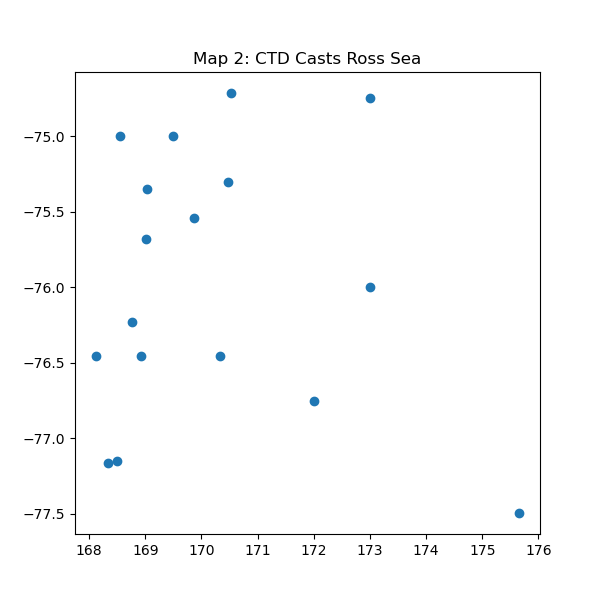

In [113]:
fig = plt.figure(figsize=(6,6))
plt.scatter(ds_sub2.lon,ds_sub2.lat)
plt.title('Map 2: CTD Casts Ross Sea')

In [114]:
ds_sub2['Absolute_Salinity'] = gsw.SA_from_SP(ds_sub2.Salinity,ds_sub2.Pressure,ds_sub2.lon,ds_sub2.lat)
# should a reference pressure of zero be used? 
ds_sub2['Potential_Temperature'] = gsw.pt_from_t(ds_sub2.Absolute_Salinity,ds_sub2.Temperature,ds_sub2.Pressure,0)
ds_sub2['Conservative_Temperature'] = gsw.CT_from_pt(ds_sub2.Absolute_Salinity,ds_sub2.Potential_Temperature)
ds_sub2['Potential_Density'] = gsw.sigma0(ds_sub2.Absolute_Salinity,ds_sub2.Conservative_Temperature)

Text(0.5, 0.98, 'Station 32, 2018-01-17')

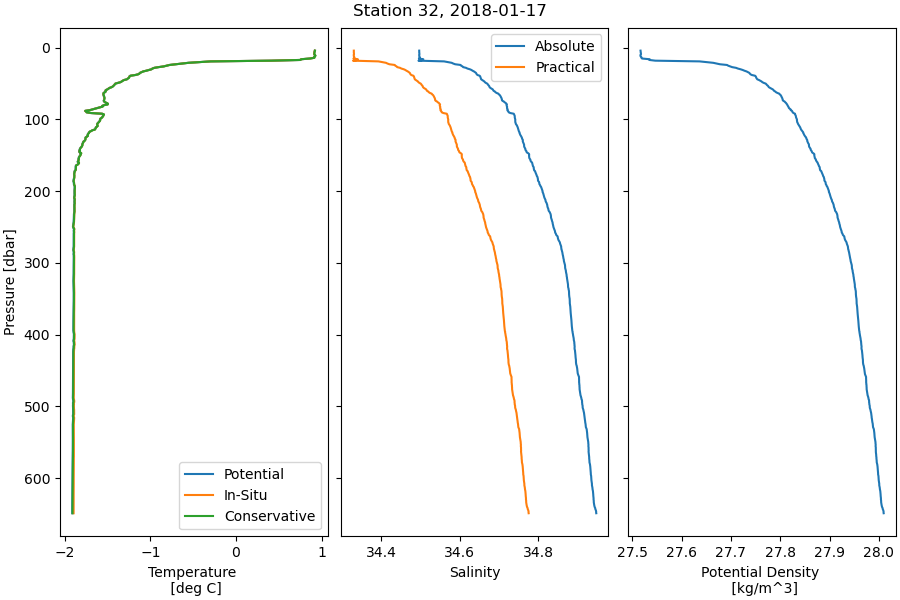

In [120]:
station = 32
ds_st = ds_sub2.sel(station=station)

fig, axes = plt.subplots(1, 3, figsize=(9,6), constrained_layout=True, sharey=True)

# 1st panel
axes[0].plot(ds_st.Potential_Temperature, ds_st.Pressure,label='Potential')
axes[0].plot(ds_st.Temperature, ds_st.Pressure,label='In-Situ')
axes[0].plot(ds_st.Conservative_Temperature, ds_st.Pressure,label='Conservative')
axes[0].legend()
axes[0].set_xlabel('Temperature \n [deg C]')
axes[0].set_ylabel('Pressure [dbar]')
axes[0].invert_yaxis()

# 2nd panel
axes[1].plot(ds_st.Absolute_Salinity, ds_st.Pressure,label='Absolute')
axes[1].plot(ds_st.Salinity, ds_st.Pressure,label='Practical')
axes[1].legend()
axes[1].set_xlabel('Salinity')
axes[1].invert_yaxis()

# 3rd panel
axes[2].plot(ds_st.Potential_Density, ds_st.Pressure)
axes[2].set_xlabel('Potential Density \n [kg/m^3]')
axes[2].invert_yaxis()

# Title
st_num = ds_st.station.item()
date = ds_sub2.Date.sel(station=station).isel(sample=0).item()

fig.suptitle(f'Station {st_num}, {date}')